In [1]:
import pandas as pd
import sqlite3
import os

# 1. Conexión a la base de datos que creaste en DBeaver
# Recuerda que '../data/' significa: "sube un nivel y entra a la carpeta data"
conn = sqlite3.connect('../data/ecommerce.db')

# 2. Lista de archivos CSV a procesar
archivos = [
    'olist_customers_dataset.csv',
    'olist_orders_dataset.csv',
    'olist_order_items_dataset.csv',
    'product_category_name_translation.csv' # ¡Añadimos este para traducir luego!
]

# 3. Proceso de importación
for archivo in archivos:
    try:
        # Quitamos los prefijos y sufijos para que el nombre de la tabla sea limpio
        nombre_tabla = archivo.replace('olist_', '').replace('_dataset.csv', '').replace('.csv', '')
        
        print(f"Procesando: {archivo} ...")
        
        # Leemos el archivo
        df = pd.read_csv(f'../data/{archivo}')
        
        # Lo enviamos a SQL
        df.to_sql(nombre_tabla, conn, if_exists='replace', index=False)
        print(f"✅ Tabla '{nombre_tabla}' creada con éxito.")
        
    except FileNotFoundError:
        print(f"❌ Error: No encontré el archivo {archivo}. Revisa si el nombre es exacto.")

# Cerramos conexión
conn.close()
print("\n--- Proceso finalizado ---")

Procesando: olist_customers_dataset.csv ...
✅ Tabla 'customers' creada con éxito.
Procesando: olist_orders_dataset.csv ...
✅ Tabla 'orders' creada con éxito.
Procesando: olist_order_items_dataset.csv ...
✅ Tabla 'order_items' creada con éxito.
Procesando: product_category_name_translation.csv ...
✅ Tabla 'product_category_name_translation' creada con éxito.

--- Proceso finalizado ---


In [1]:
import pandas as pd
import sqlite3

# Conectamos a la base de datos
conn = sqlite3.connect('../data/ecommerce.db')

# Lista completa de archivos para un portafolio profesional
archivos_restantes = [
    'olist_products_dataset.csv',
    'olist_sellers_dataset.csv',
    'olist_order_reviews_dataset.csv',
    'olist_geolocation_dataset.csv'
]

for archivo in archivos_restantes:
    try:
        nombre_tabla = archivo.replace('olist_', '').replace('_dataset.csv', '').replace('.csv', '')
        print(f"Importando: {archivo}...")
        
        # Leemos y guardamos en SQL
        df = pd.read_csv(f'../data/{archivo}')
        df.to_sql(nombre_tabla, conn, if_exists='replace', index=False)
        print(f"✅ Tabla '{nombre_tabla}' lista.")
        
    except FileNotFoundError:
        print(f"⚠️ No se encontró {archivo}, verifica el nombre en la carpeta /data")

conn.close()
print("\n¡Base de datos completada con éxito!")

Importando: olist_products_dataset.csv...
✅ Tabla 'products' lista.
Importando: olist_sellers_dataset.csv...
✅ Tabla 'sellers' lista.
Importando: olist_order_reviews_dataset.csv...
✅ Tabla 'order_reviews' lista.
Importando: olist_geolocation_dataset.csv...
✅ Tabla 'geolocation' lista.

¡Base de datos completada con éxito!


In [2]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

# Conectamos
conn = sqlite3.connect('../data/ecommerce.db')

# Traemos el Top 10 de categorías por facturación (el que ya hiciste en DBeaver)
query = """
SELECT 
    t.product_category_name_english AS categoria,
    SUM(i.price) AS facturacion
FROM order_items i
JOIN products p ON i.product_id = p.product_id
JOIN product_category_name_translation t ON p.product_category_name = t.product_category_name
GROUP BY categoria
ORDER BY facturacion DESC
LIMIT 10;
"""

df_ventas = pd.read_sql_query(query, conn)

# Creamos el gráfico
plt.figure(figsize=(12, 6))
sns.barplot(data=df_ventas, x='facturacion', y='categoria', palette='viridis')
plt.title('Top 10 Categorías por Facturación (USD)')
plt.xlabel('Facturación Total')
plt.ylabel('Categoría')
plt.show()

conn.close()

ModuleNotFoundError: No module named 'seaborn'

In [3]:
!pip install seaborn

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

/tmp/ipykernel_7543/3626593208.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_ventas, x='facturacion', y='categoria', palette='viridis')


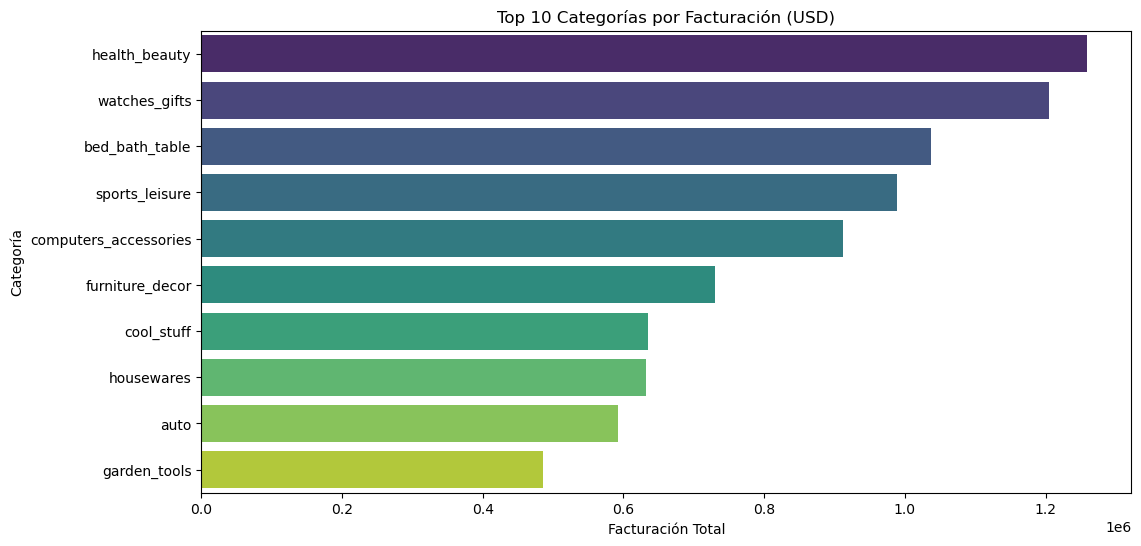

In [4]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

# Conectamos
conn = sqlite3.connect('../data/ecommerce.db')

# Traemos el Top 10 de categorías por facturación (el que ya hiciste en DBeaver)
query = """
SELECT 
    t.product_category_name_english AS categoria,
    SUM(i.price) AS facturacion
FROM order_items i
JOIN products p ON i.product_id = p.product_id
JOIN product_category_name_translation t ON p.product_category_name = t.product_category_name
GROUP BY categoria
ORDER BY facturacion DESC
LIMIT 10;
"""

df_ventas = pd.read_sql_query(query, conn)

# Creamos el gráfico
plt.figure(figsize=(12, 6))
sns.barplot(data=df_ventas, x='facturacion', y='categoria', palette='viridis')
plt.title('Top 10 Categorías por Facturación (USD)')
plt.xlabel('Facturación Total')
plt.ylabel('Categoría')
plt.show()

conn.close()

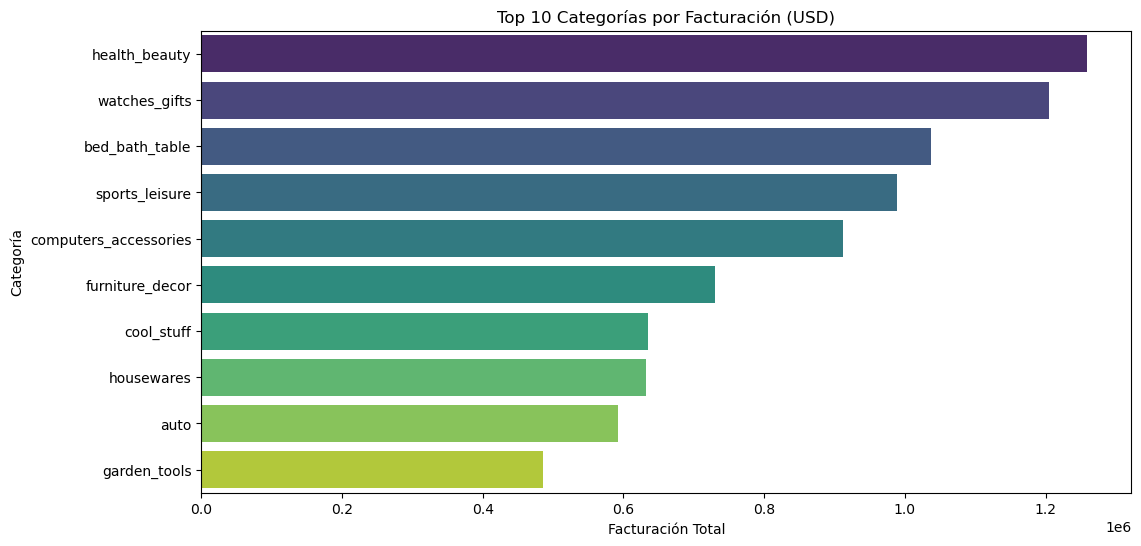

In [5]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

# Conectamos a la base de datos
conn = sqlite3.connect('../data/ecommerce.db')

# Consulta SQL para el Top 10 de facturación
query = """
SELECT 
    t.product_category_name_english AS categoria,
    SUM(i.price) AS facturacion
FROM order_items i
JOIN products p ON i.product_id = p.product_id
JOIN product_category_name_translation t ON p.product_category_name = t.product_category_name
GROUP BY categoria
ORDER BY facturacion DESC
LIMIT 10;
"""

df_ventas = pd.read_sql_query(query, conn)

# Configuración del gráfico
plt.figure(figsize=(12, 6))
# Usamos hue='categoria' para evitar el FutureWaring
sns.barplot(data=df_ventas, x='facturacion', y='categoria', hue='categoria', palette='viridis', legend=False)

plt.title('Top 10 Categorías por Facturación (USD)')
plt.xlabel('Facturación Total')
plt.ylabel('Categoría')

plt.show()
conn.close()

El tiempo promedio de entrega es de: 12.56 días
La mediana de entrega es de: 10.22 días


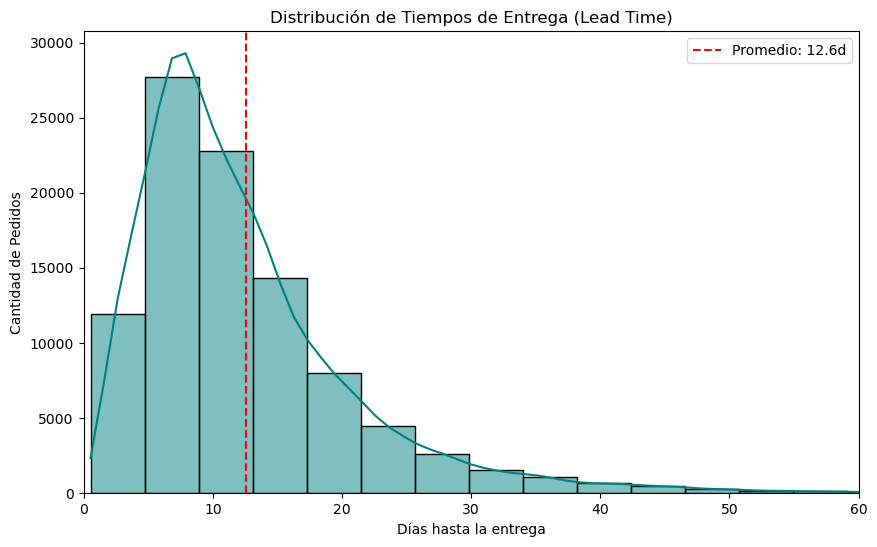

In [6]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect('../data/ecommerce.db')

# Consulta para calcular días de entrega
# Usamos julianday() de SQLite para restar las fechas y obtener los días
query_logistica = """
SELECT 
    order_id,
    order_purchase_timestamp,
    order_delivered_customer_date,
    (julianday(order_delivered_customer_date) - julianday(order_purchase_timestamp)) AS dias_entrega
FROM orders
WHERE order_status = 'delivered' 
  AND order_delivered_customer_date IS NOT NULL;
"""

df_logistica = pd.read_sql_query(query_logistica, conn)

# Calculamos estadísticas básicas
promedio = df_logistica['dias_entrega'].mean()
mediana = df_logistica['dias_entrega'].median()

print(f"El tiempo promedio de entrega es de: {promedio:.2f} días")
print(f"La mediana de entrega es de: {mediana:.2f} días")

# Graficamos la distribución de los tiempos
plt.figure(figsize=(10, 6))
sns.histplot(df_logistica['dias_entrega'], bins=50, kde=True, color='teal')
plt.axvline(promedio, color='red', linestyle='--', label=f'Promedio: {promedio:.1f}d')
plt.title('Distribución de Tiempos de Entrega (Lead Time)')
plt.xlabel('Días hasta la entrega')
plt.ylabel('Cantidad de Pedidos')
plt.xlim(0, 60) # Limitamos a 60 días para ver mejor el gráfico
plt.legend()
plt.show()

conn.close()

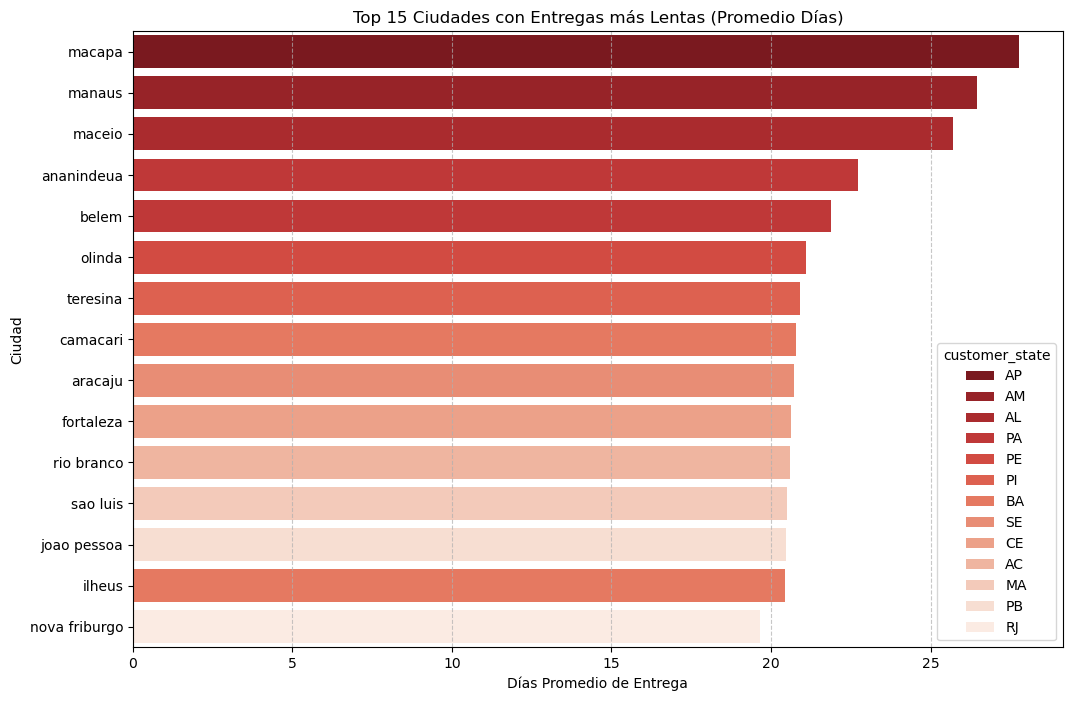

In [7]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect('../data/ecommerce.db')

# Consulta para ver el tiempo promedio de entrega por ciudad
query_ciudades_lentas = """
SELECT 
    c.customer_city,
    c.customer_state,
    AVG(julianday(o.order_delivered_customer_date) - julianday(o.order_purchase_timestamp)) AS promedio_dias
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered' 
  AND o.order_delivered_customer_date IS NOT NULL
GROUP BY c.customer_city
HAVING COUNT(o.order_id) > 50 -- Filtramos ciudades con pocos pedidos para que el dato sea real
ORDER BY promedio_dias DESC
LIMIT 15;
"""

df_lentas = pd.read_sql_query(query_ciudades_lentas, conn)

# Graficamos el Top 15 de ciudades más lentas
plt.figure(figsize=(12, 8))
sns.barplot(data=df_lentas, x='promedio_dias', y='customer_city', hue='customer_state', palette='Reds_r')

plt.title('Top 15 Ciudades con Entregas más Lentas (Promedio Días)')
plt.xlabel('Días Promedio de Entrega')
plt.ylabel('Ciudad')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

conn.close()

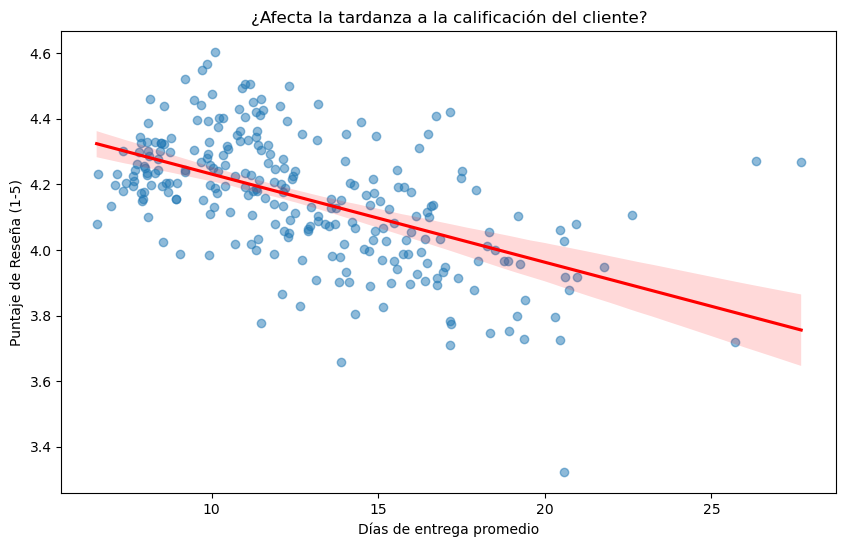

In [8]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect('../data/ecommerce.db')

query_satisfaccion_logistica = """
SELECT 
    c.customer_city,
    AVG(julianday(o.order_delivered_customer_date) - julianday(o.order_purchase_timestamp)) AS dias_entrega,
    AVG(r.review_score) AS puntaje_resena
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
JOIN order_reviews r ON o.order_id = r.order_id
WHERE o.order_status = 'delivered' 
  AND o.order_delivered_customer_date IS NOT NULL
GROUP BY c.customer_city
HAVING COUNT(o.order_id) > 50
"""

df_correlacion = pd.read_sql_query(query_satisfaccion_logistica, conn)

# Graficamos la correlación
plt.figure(figsize=(10, 6))
sns.regplot(data=df_correlacion, x='dias_entrega', y='puntaje_resena', 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

plt.title('¿Afecta la tardanza a la calificación del cliente?')
plt.xlabel('Días de entrega promedio')
plt.ylabel('Puntaje de Reseña (1-5)')
plt.show()

conn.close()

TypeError: subplots_adjust() got an unexpected keyword argument 'wsize'

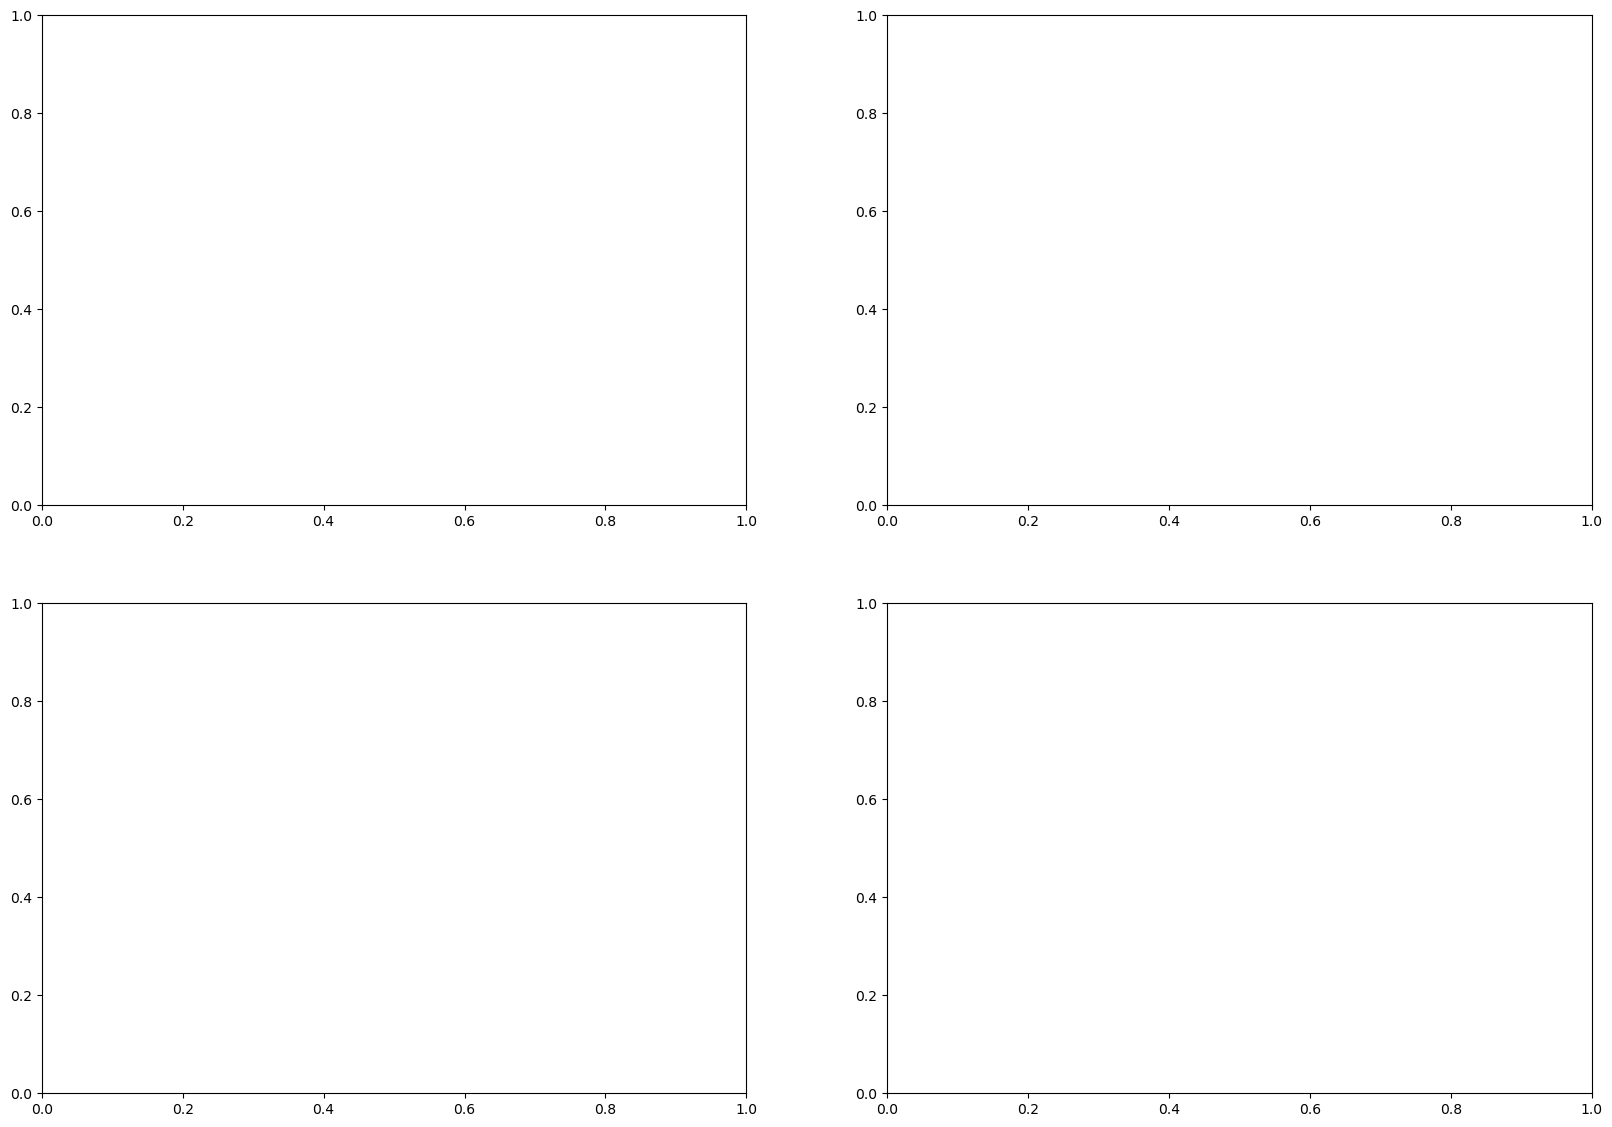

In [9]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect('../data/ecommerce.db')

# Configuramos el lienzo del dashboard (2 filas, 2 columnas)
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
plt.subplots_adjust(hspace=0.4, wsize=0.3)
fig.suptitle('Dashboard Ejecutivo: Análisis de E-commerce y Logística', fontsize=24, fontweight='bold')

# 1. Top Ventas (Arriba Izquierda)
query1 = "SELECT t.product_category_name_english as cat, SUM(i.price) as vta FROM order_items i JOIN products p ON i.product_id = p.product_id JOIN product_category_name_translation t ON p.product_category_name = t.product_category_name GROUP BY 1 ORDER BY 2 DESC LIMIT 8"
df1 = pd.read_sql_query(query1, conn)
sns.barplot(ax=axes[0,0], data=df1, x='vta', y='cat', hue='cat', palette='viridis', legend=False)
axes[0,0].set_title('Top 8 Categorías por Ingresos', fontsize=15)

# 2. Histograma de Entregas (Arriba Derecha)
query2 = "SELECT (julianday(order_delivered_customer_date) - julianday(order_purchase_timestamp)) as dias FROM orders WHERE order_status='delivered' AND dias IS NOT NULL"
df2 = pd.read_sql_query(query2, conn)
sns.histplot(ax=axes[0,1], data=df2['dias'], bins=50, kde=True, color='teal')
axes[0,1].set_xlim(0, 45)
axes[0,1].set_title('Distribución de Tiempos de Entrega (Días)', fontsize=15)

# 3. Ciudades Críticas (Abajo Izquierda)
query3 = "SELECT c.customer_city as city, AVG(julianday(o.order_delivered_customer_date) - julianday(o.order_purchase_timestamp)) as dias FROM orders o JOIN customers c ON o.customer_id = c.customer_id WHERE o.order_status='delivered' GROUP BY 1 HAVING COUNT(o.order_id) > 50 ORDER BY 2 DESC LIMIT 8"
df3 = pd.read_sql_query(query3, conn)
sns.barplot(ax=axes[1,0], data=df3, x='dias', y='city', hue='city', palette='Reds_r', legend=False)
axes[1,0].set_title('Ciudades con Logística más Lenta (Cuellos de Botella)', fontsize=15)

# 4. Correlación Satisfacción (Abajo Derecha)
query4 = "SELECT AVG(julianday(o.order_delivered_customer_date) - julianday(o.order_purchase_timestamp)) as dias, AVG(r.review_score) as score FROM orders o JOIN order_reviews r ON o.order_id = r.order_id WHERE o.order_status='delivered' GROUP BY o.order_id"
# Para el scatter del dashboard usamos una muestra aleatoria para que sea más legible
df4 = pd.read_sql_query(query4, conn).sample(1000) 
sns.regplot(ax=axes[1,1], data=df4, x='dias', y='score', scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
axes[1,1].set_title('Impacto de la Tardanza en la Calificación', fontsize=15)

plt.show()
conn.close()

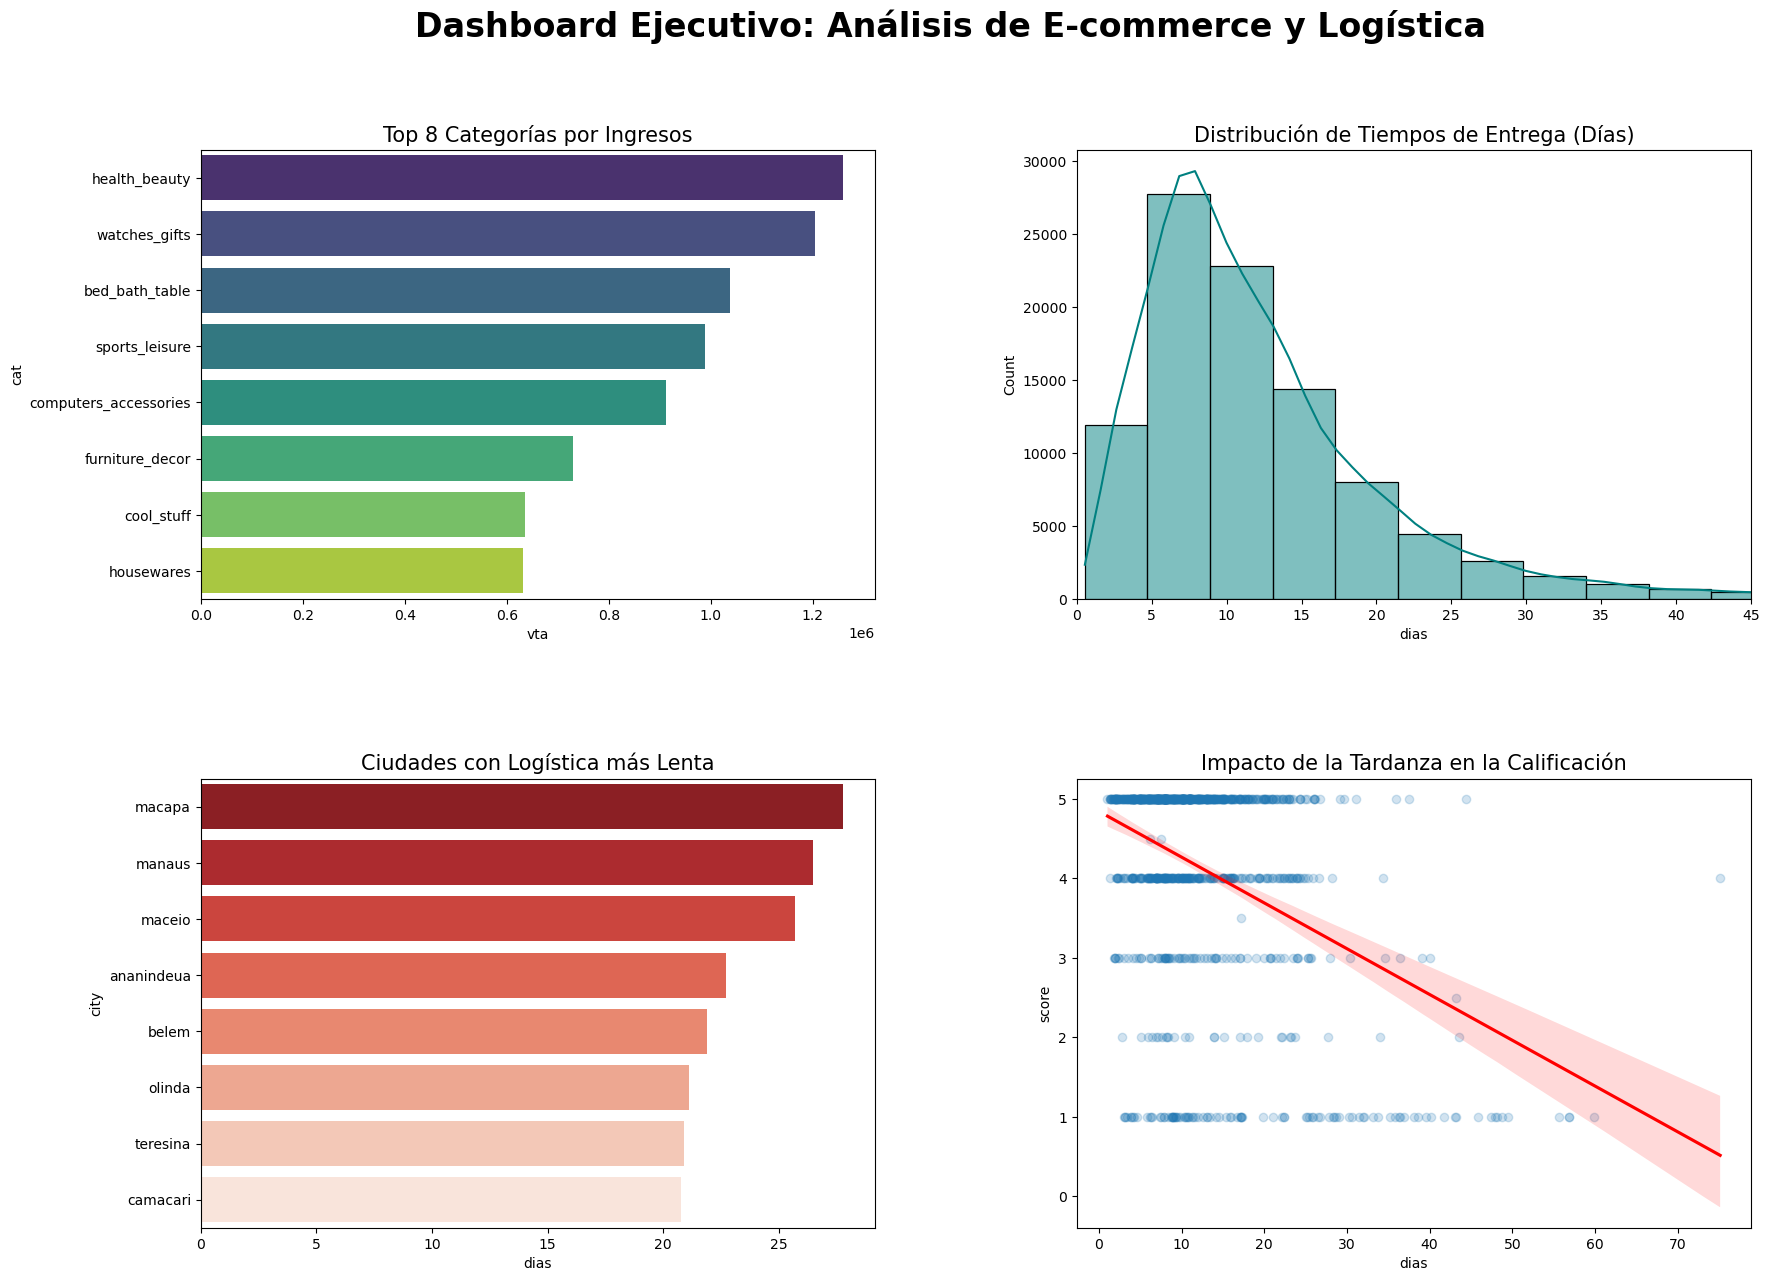

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect('../data/ecommerce.db')

# Configuramos el lienzo del dashboard (2 filas, 2 columnas)
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
# CORRECCIÓN: 'wspace' en lugar de 'wsize'
plt.subplots_adjust(hspace=0.4, wspace=0.3) 
fig.suptitle('Dashboard Ejecutivo: Análisis de E-commerce y Logística', fontsize=24, fontweight='bold')

# 1. Top Ventas (Arriba Izquierda)
query1 = """
SELECT t.product_category_name_english as cat, SUM(i.price) as vta 
FROM order_items i 
JOIN products p ON i.product_id = p.product_id 
JOIN product_category_name_translation t ON p.product_category_name = t.product_category_name 
GROUP BY 1 ORDER BY 2 DESC LIMIT 8
"""
df1 = pd.read_sql_query(query1, conn)
sns.barplot(ax=axes[0,0], data=df1, x='vta', y='cat', hue='cat', palette='viridis', legend=False)
axes[0,0].set_title('Top 8 Categorías por Ingresos', fontsize=15)

# 2. Histograma de Entregas (Arriba Derecha)
query2 = """
SELECT (julianday(order_delivered_customer_date) - julianday(order_purchase_timestamp)) as dias 
FROM orders 
WHERE order_status='delivered' AND order_delivered_customer_date IS NOT NULL
"""
df2 = pd.read_sql_query(query2, conn)
sns.histplot(ax=axes[0,1], data=df2['dias'], bins=50, kde=True, color='teal')
axes[0,1].set_xlim(0, 45)
axes[0,1].set_title('Distribución de Tiempos de Entrega (Días)', fontsize=15)

# 3. Ciudades Críticas (Abajo Izquierda)
query3 = """
SELECT c.customer_city as city, AVG(julianday(o.order_delivered_customer_date) - julianday(o.order_purchase_timestamp)) as dias 
FROM orders o 
JOIN customers c ON o.customer_id = c.customer_id 
WHERE o.order_status='delivered' AND o.order_delivered_customer_date IS NOT NULL
GROUP BY 1 HAVING COUNT(o.order_id) > 50 ORDER BY 2 DESC LIMIT 8
"""
df3 = pd.read_sql_query(query3, conn)
sns.barplot(ax=axes[1,0], data=df3, x='dias', y='city', hue='city', palette='Reds_r', legend=False)
axes[1,0].set_title('Ciudades con Logística más Lenta', fontsize=15)

# 4. Correlación Satisfacción (Abajo Derecha)
query4 = """
SELECT 
    AVG(julianday(o.order_delivered_customer_date) - julianday(o.order_purchase_timestamp)) as dias, 
    AVG(r.review_score) as score 
FROM orders o 
JOIN order_reviews r ON o.order_id = r.order_id 
WHERE o.order_status='delivered' AND o.order_delivered_customer_date IS NOT NULL
GROUP BY o.order_id
"""
df4 = pd.read_sql_query(query4, conn)
# Usamos una muestra para que el gráfico no sea pesado
df4_sample = df4.sample(min(1000, len(df4))) 
sns.regplot(ax=axes[1,1], data=df4_sample, x='dias', y='score', scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
axes[1,1].set_title('Impacto de la Tardanza en la Calificación', fontsize=15)

plt.show()
conn.close()